In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/reduceddata.zip'
extract_path = '/content/'

if not os.path.exists(zip_path):
    print(f"Error: Zip file not found at {zip_path}")
else:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_path}' extracted to '{extract_path}'")
    # Verify extraction
    print("Contents of extracted directory:")
    print(os.listdir(os.path.join(extract_path, 'train'))) # Assuming 'train' is directly inside the zip

'/content/drive/MyDrive/reduceddata.zip' extracted to '/content/'
Contents of extracted directory:
['Apple___Apple_scab', 'Blast', 'Bacterialblight', 'Apple___Black_rot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___Esca_(Black_Measles)', 'Grape___Black_rot', 'Apple___Cedar_apple_rust', 'Brownspot', 'Corn_(maize)___Northern_Leaf_Blight']


### Preparing the Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
train_dir = os.path.join(extract_path, 'train')

# Set image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation and splitting (80/20 split)
# The validation_split parameter applies to the generator, creating a split within the directory.
# For the specified augmentation, these will be added to the model as a Sequential layer.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 # 80% for training
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 # 20% for validation
)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical'
)

# Get the number of classes from the generators
num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")


Found 5272 images belonging to 12 classes.
Found 1311 images belonging to 12 classes.
Number of classes: 12


### Model Definition

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Data augmentation layers
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

# Base MobileNetV2 model (pre-trained on ImageNet)
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                          include_top=False,
                          weights='imagenet')

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Build the complete model
model = Sequential([
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dense(num_classes, activation='softmax')
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

### Model Training

In [ ]:
EPOCHS = 30

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.7910 - loss: 0.6819 - val_accuracy: 0.8688 - val_loss: 0.3819
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.9200 - loss: 0.2600 - val_accuracy: 0.8894 - val_loss: 0.2957
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9448 - loss: 0.1852 - val_accuracy: 0.9115 - val_loss: 0.2471
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9539 - loss: 0.1507 - val_accuracy: 0.9092 - val_loss: 0.2397
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9598 - loss: 0.1308 - val_accuracy: 0.9291 - val_loss: 0.2083
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9698 - loss: 0.1060 - val_accuracy: 0.9230 - val_loss: 0.2070
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.9685 - loss: 0.1009 - val_accuracy: 0.9306 - val_loss: 0.1976
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9698 - loss: 0.0961 - val_accu

### Model Conversion to TFLite

In [ ]:
import tensorflow as tf

# Convert the Keras model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable basic optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save the TFLite model to a file
with open('final_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model converted to TFLite and saved as 'final_model.tflite'")


NameError: name 'model' is not defined

### Visualization: Training/Validation Accuracy and Loss Curves

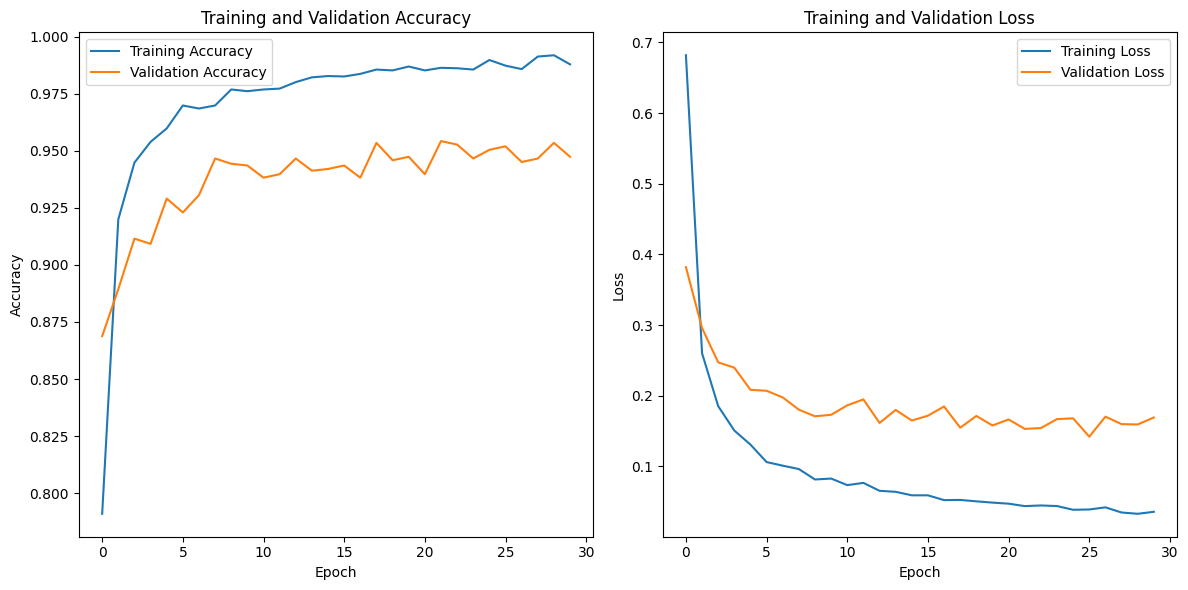

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


### Input/Output Prediction

Class names (first 5): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Bacterialblight', 'Blast']
Class names (last 5): ['Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)']
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


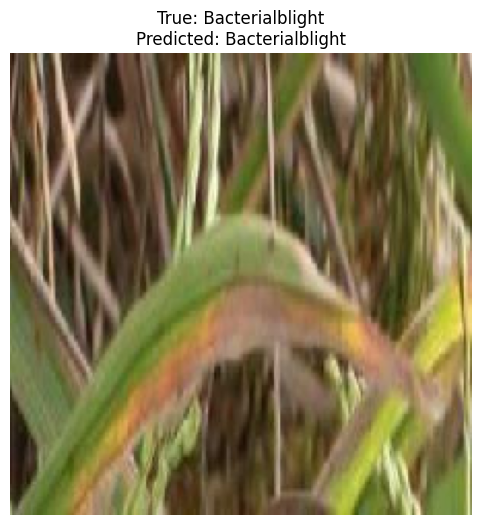

In [ ]:
# Get class names from the train_generator
class_names = list(train_generator.class_indices.keys())
print(f"Class names (first 5): {class_names[:5]}")
print(f"Class names (last 5): {class_names[-5:]}")

# Get a sample image and its true label from the validation generator
sample_images, sample_labels = next(validation_generator)
single_sample_image = sample_images[0] # Take the first image
single_sample_label = sample_labels[0] # Take its label

# Get the true class name
true_class_index = tf.argmax(single_sample_label).numpy()
true_class_name = class_names[true_class_index]

# Preprocess the image for prediction (add batch dimension)
input_image_for_prediction = tf.expand_dims(single_sample_image, axis=0)

# Make prediction
predictions = model.predict(input_image_for_prediction)
predicted_class_index = tf.argmax(predictions[0]).numpy()
predicted_class_name = class_names[predicted_class_index]

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(single_sample_image)
plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name}")
plt.axis('off')
plt.show()


In [ ]:
print("Class names and their integer indices:")
print(train_generator.class_indices)

Class names and their integer indices:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Bacterialblight': 3, 'Blast': 4, 'Brownspot': 5, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 6, 'Corn_(maize)___Common_rust_': 7, 'Corn_(maize)___Northern_Leaf_Blight': 8, 'Grape___Black_rot': 9, 'Grape___Esca_(Black_Measles)': 10, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 11}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


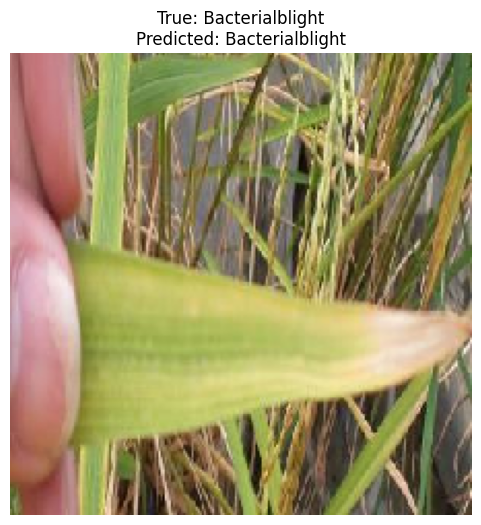

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


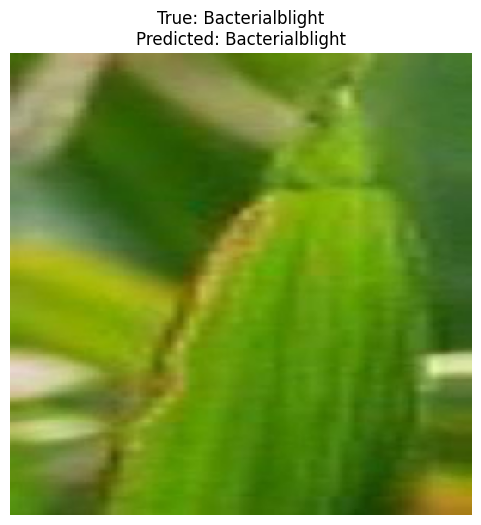

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


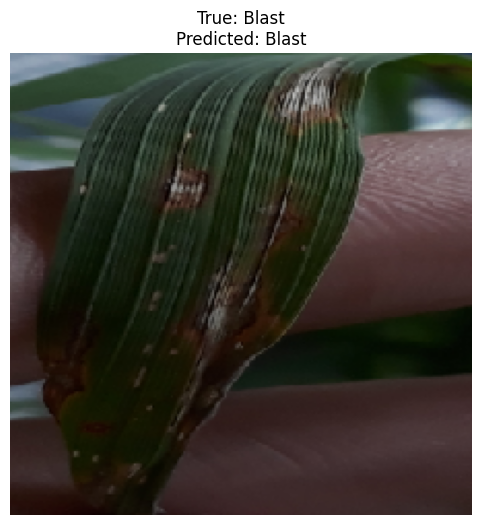

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


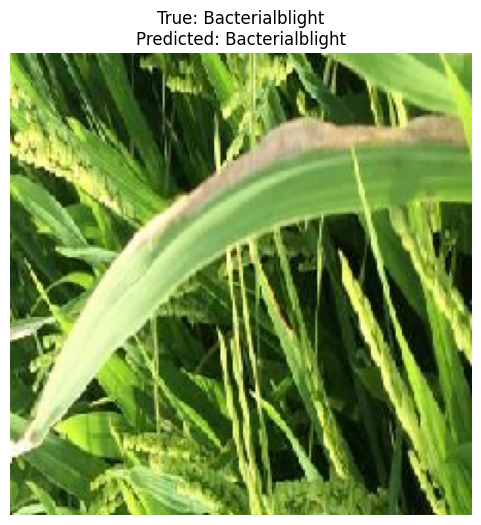

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


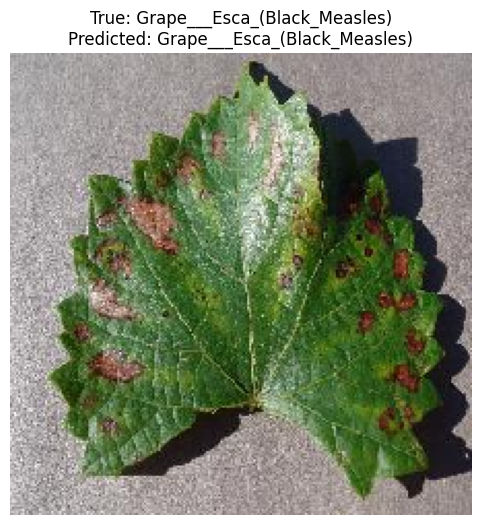

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    # Get a new sample image and its true label from the validation generator
    sample_images, sample_labels = next(validation_generator)
    single_sample_image = sample_images[0]
    single_sample_label = sample_labels[0]

    # Get the true class name
    true_class_index = tf.argmax(single_sample_label).numpy()
    true_class_name = class_names[true_class_index]

    # Preprocess the image for prediction (add batch dimension)
    input_image_for_prediction = tf.expand_dims(single_sample_image, axis=0)

    # Make prediction
    predictions = model.predict(input_image_for_prediction)
    predicted_class_index = tf.argmax(predictions[0]).numpy()
    predicted_class_name = class_names[predicted_class_index]

    plt.figure(figsize=(6, 6))
    plt.imshow(single_sample_image)
    plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name}")
    plt.axis('off')
    plt.show()